In [ ]:
  import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

In [ ]:
url = "https://huggingface.co/datasets/ShiroOnigami23/skin-cancer-ham10000-dataset/resolve/main/HAM10000_metadata.csv"
df = pd.read_csv(url)

print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")
print(df.head())

Loaded 10,015 rows x 7 columns
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


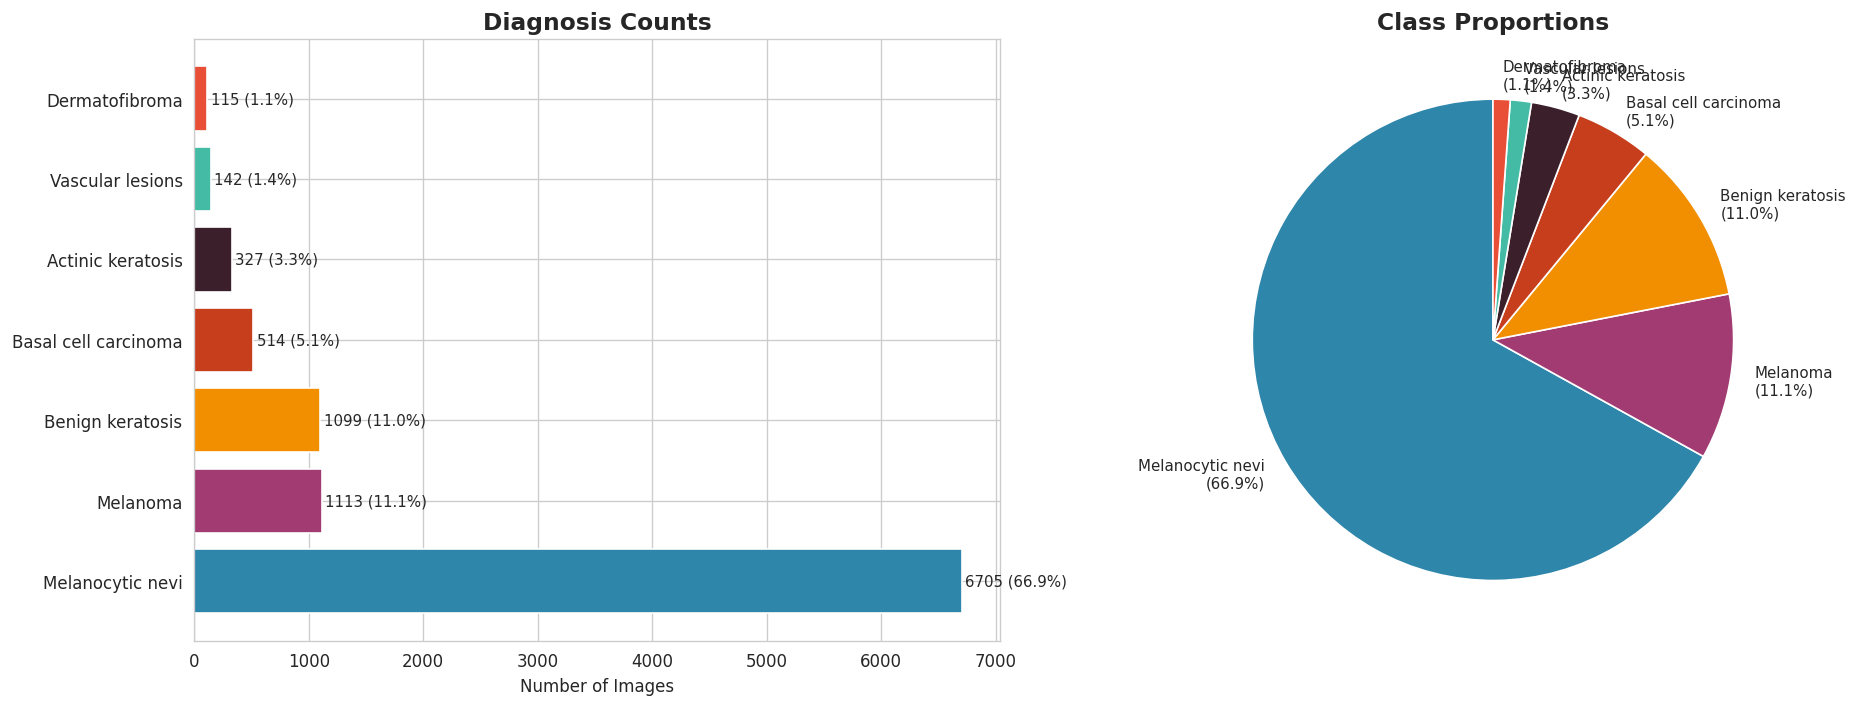

In [ ]:
dx_counts = df['dx'].value_counts()
dx_pct = df['dx'].value_counts(normalize=True) * 100

dx_labels = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratosis',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

full_labels = [dx_labels[dx] for dx in dx_counts.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44BBA4', '#E94F37']

bars = ax1.barh(full_labels, dx_counts.values, color=colors)
ax1.set_title('Diagnosis Counts', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Images')
for i, (bar, val) in enumerate(zip(bars, dx_counts.values)):
    pct = dx_pct.iloc[i]
    ax1.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f"{val} ({pct:.1f}%)",
            va='center', fontsize=9)

wedges, texts = ax2.pie(
    dx_counts.values, labels=[f"{l}\n({p:.1f}%)" for l, p in zip(full_labels, dx_pct.values)],
    colors=colors, startangle=90,
    textprops={'fontsize': 9}
)
ax2.set_title('Class Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

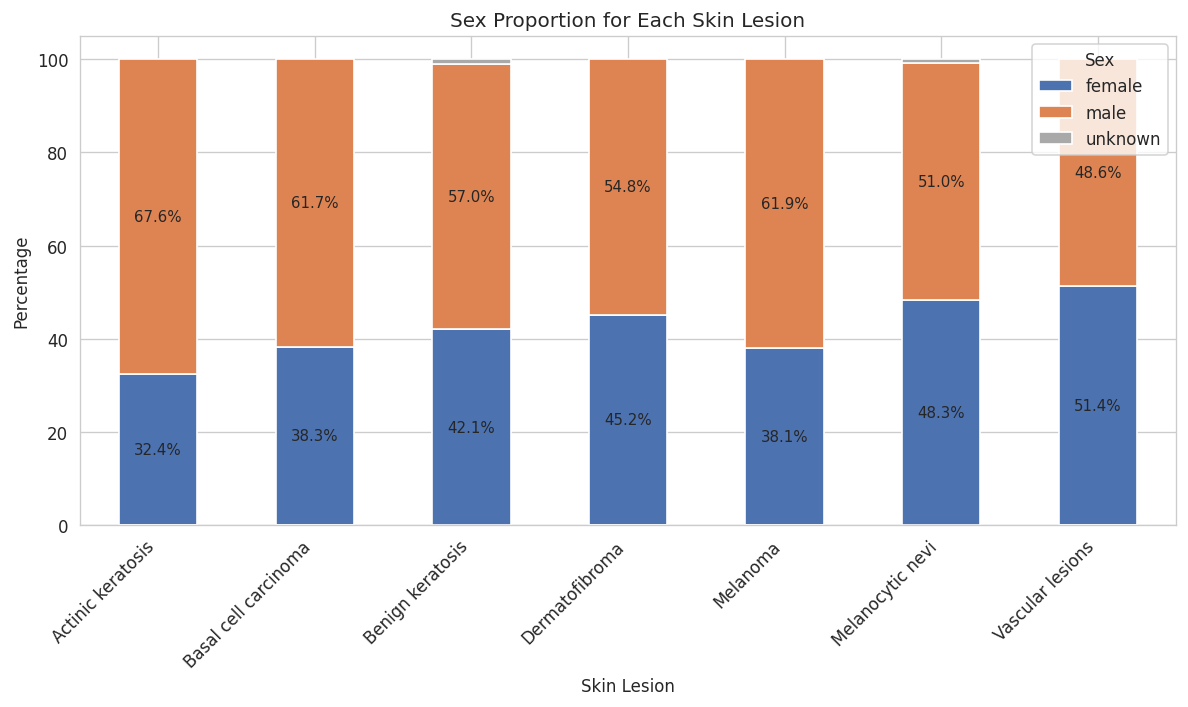

In [ ]:
sex_dx_prop = pd.crosstab(df['dx'], df['sex'], normalize='index') * 100

sex_dx_prop.index = [dx_labels[d] for d in sex_dx_prop.index]

ax = sex_dx_prop.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=['#4C72B0', '#DD8452', '#A9A9A9']
)

plt.title('Sex Proportion for Each Skin Lesion')
plt.xlabel('Skin Lesion')
plt.ylabel('Percentage')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sex')

for container in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 3 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9)

plt.tight_layout()
plt.show()

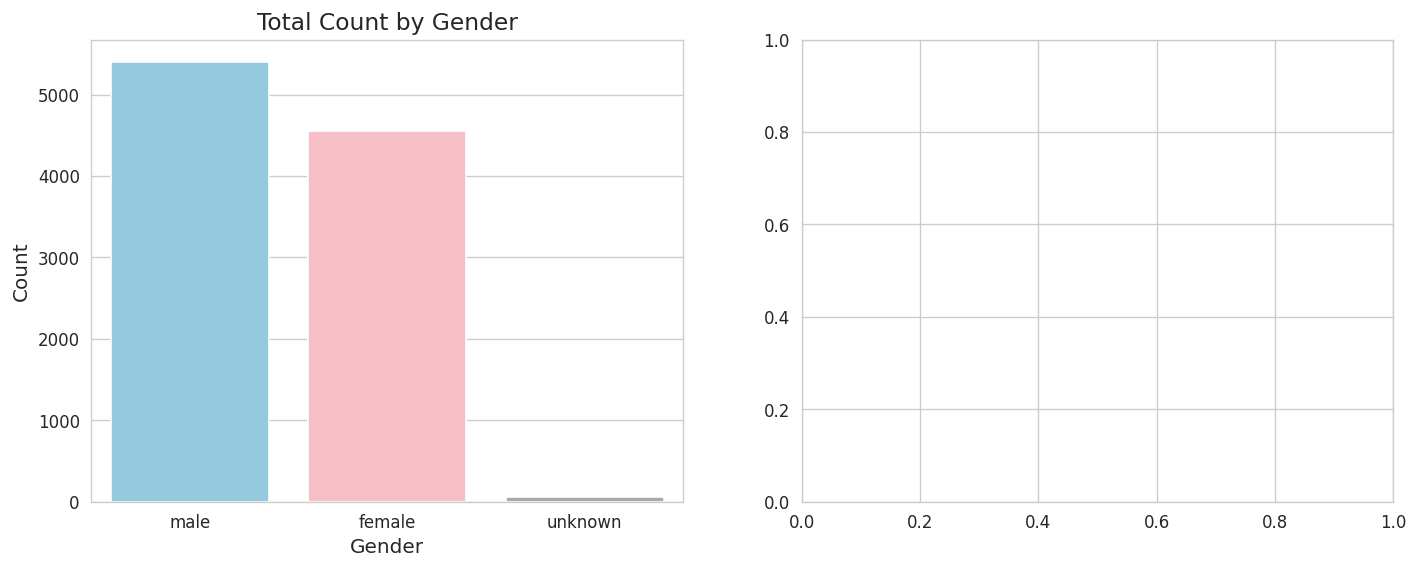

In [ ]:
# 3. Clean up the data (Optional: removes empty gender rows)
df = df.dropna(subset=['sex'])

# 4. Set up the plotting window (1 row, 2 columns for side-by-side plots)
fig, axes = plt.subplots(1,2, figsize=(14, 5))

# Plot A: Total Counts (Categorical)
sns.countplot(
    ax=axes[0],
    x='sex',
    data=df,
    palette=['skyblue', 'lightpink', '#A9A9A9']
)
axes[0].set_title('Total Count by Gender', fontsize=14)
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# 5. Display the plot
plt.show()

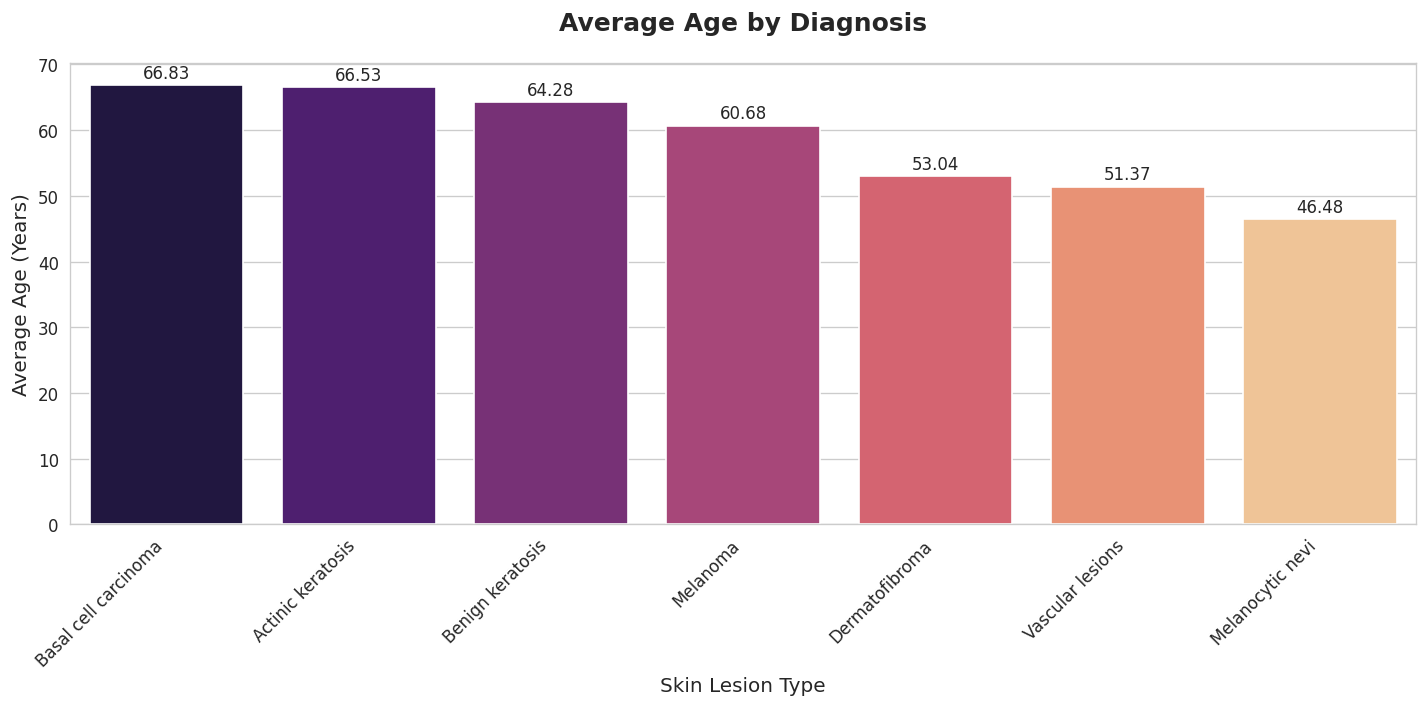

In [ ]:
average_age = df.groupby('dx')['age'].mean().sort_values(ascending=False).reset_index()
average_age['diagnosis'] = average_age['dx'].map(dx_labels)

plt.figure(figsize=(12, 6))
plot = sns.barplot(x='diagnosis',y='age', data=average_age, palette='magma')
plt.title('Average Age by Diagnosis',fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Skin Lesion Type', fontsize=12)
plt.ylabel('Average Age (Years)', fontsize=12)
plt.xticks(rotation=45, ha='right')

for container in plot.containers:
    plot.bar_label(container, fmt='%.2f', padding=2)

plt.tight_layout()
plt.show()

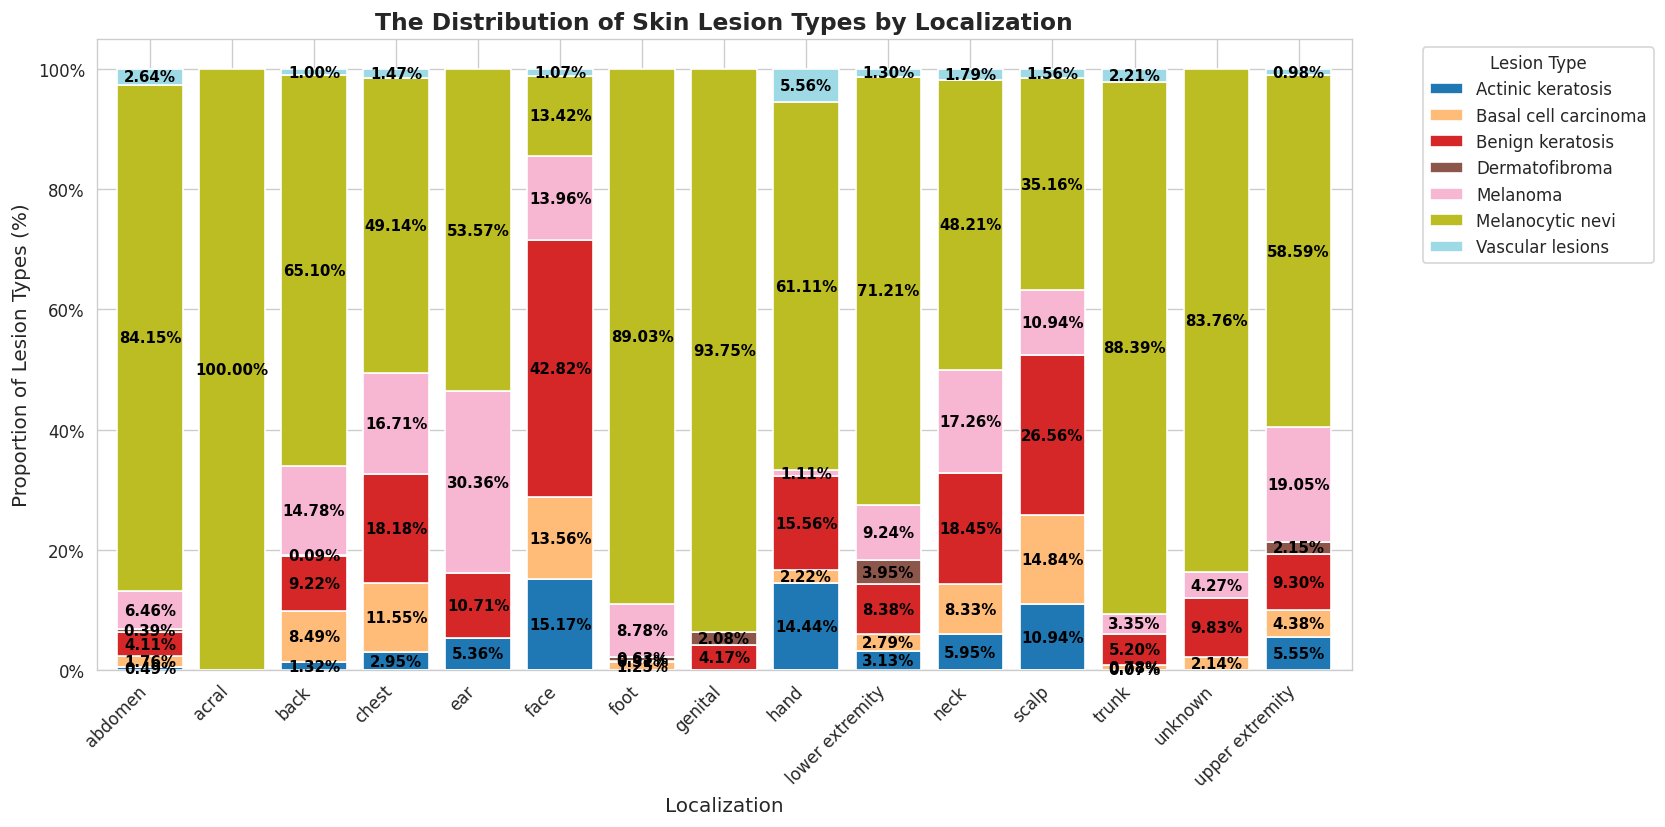

In [ ]:
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(14, 7))

localization_dx_proportions.plot(kind='bar', stacked=True, ax=ax, cmap='tab20', width=0.8)

ax.set_xlabel('Localization', fontsize=12)
ax.set_ylabel('Proportion of Lesion Types (%)', fontsize=12)
ax.set_title('The Distribution of Skin Lesion Types by Localization', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.setp(ax.get_xticklabels(), ha='right') # Set horizontal alignment for tick labels
ax.legend(title='Lesion Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Format y-axis to show percentages
formatter = mticker.PercentFormatter(xmax=1.0) # xmax=1.0 because data is already normalized to 0-1
ax.yaxis.set_major_formatter(formatter)

# Add labels to the stacked bars with improved visibility
for container in ax.containers:
    labels = [f'{v.get_height():.2%}' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=9, color='black', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
malignant_dx = ['mel', 'bcc', 'akiec']
benign_dx = ['nv', 'bkl', 'vasc', 'df']

def classify_cancer_type(dx):
    if dx in malignant_dx:
        return 'Malignant'
    elif dx in benign_dx:
        return 'Benign'
    else:
        return 'Unknown'

df['cancer_type'] = df['dx'].apply(classify_cancer_type)

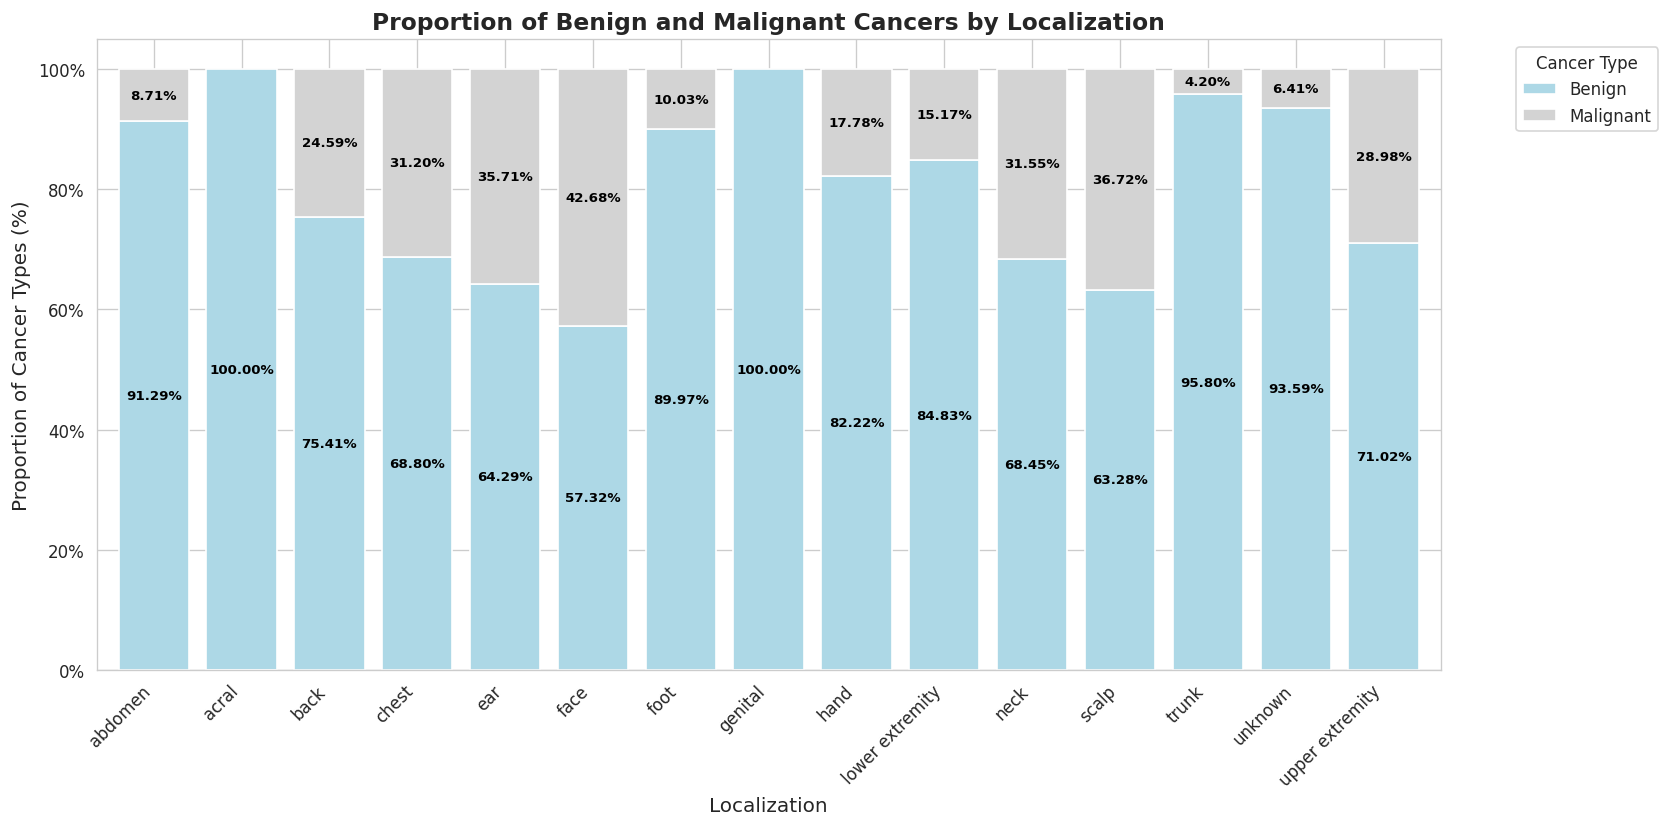

In [ ]:
import matplotlib.ticker as mticker

localization_cancer_type_proportions = pd.crosstab(df['localization'], df['cancer_type'], normalize='index')

fig, ax = plt.subplots(figsize=(14, 7))

#Set bar colors
localization_cancer_type_proportions.plot(kind='bar', stacked=True, ax=ax, color=['lightblue', 'lightgrey'], width=0.8)

#Axises labeling
ax.set_xlabel('Localization', fontsize=12)
ax.set_ylabel('Proportion of Cancer Types (%)', fontsize=12)
ax.set_title('Proportion of Benign and Malignant Cancers by Localization', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.setp(ax.get_xticklabels(), ha='right')
ax.legend(title='Cancer Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Format y-axis to show percentages
formatter = mticker.PercentFormatter(xmax=1.0) # xmax=1.0 because data is already normalized to 0-1
ax.yaxis.set_major_formatter(formatter)

# Add labels to the stacked bars
for container in ax.containers:
    labels = [f'{v.get_height():.2%}' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', fontsize=8, color='black', fontweight='bold')

plt.tight_layout()
plt.show()